In [1]:
import pandas as pd
import numpy as np
import spacy as sp

In [2]:
df = pd.read_csv('email.csv')
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Cleaning Text Data


In [3]:
# Stop words
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stopword = stopwords.words('english')
def remove_stopwords(text):
    new_text = []
    
    for word in text.split():
        if word in stopword:
            pass
        else:
            new_text.append(word)
    return " ".join(new_text)

[nltk_data] Downloading package stopwords to /home/shk/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
# remove contractions
import contractions
def remove_contractions(text):
    return contractions.fix(text)

In [5]:
from string import punctuation
def remove_punctuations(text):
    new_text = []
    
    for word in text.split():
        if word in punctuation:
            pass
        else:
            new_text.append(word)
    return " ".join(new_text)

In [6]:
nlp = sp.load("en_core_web_sm")

In [7]:
df['Message'] = df['Message'].apply(remove_punctuations)

In [8]:
df['Message'] = df['Message'].apply(remove_contractions)

In [9]:
df['Message'] = df['Message'].apply(remove_stopwords)
df.head()

,Category,Message
0,ham,"Go jurong point, crazy.. Available bugis n gre..."
1,ham,Ok lar... Joking wif oni...
2,spam,Free entry 2 wkly comp win FA Cup final tkts 2...
3,ham,YOU dun say early hor... YOU c already say...
4,ham,"Nah I think goes usf, lives around though"


In [10]:
df['Message'] = df['Message'].apply(lambda x: nlp(x))
df.head()

,Category,Message
0,ham,"(Go, jurong, point, ,, crazy, .., Available, b..."
1,ham,"(Ok, lar, ..., Joking, wif, oni, ...)"
2,spam,"(Free, entry, 2, wkly, comp, win, FA, Cup, fin..."
3,ham,"(YOU, dun, say, early, hor, ..., YOU, c, alrea..."
4,ham,"(Nah, I, think, goes, usf, ,, lives, around, t..."


In [11]:
df['token_count'] = df['Message'].apply(lambda x: len([token for token in x]))
df['sent_count'] = df['Message'].apply(lambda x: len([sent for sent in x.sents]))
df['puns_count'] = df['Message'].apply(lambda x: len([token for token in x if token.pos_ == "PUNCT"]))
df.head()

,Category,Message,token_count,sent_count,puns_count
0,ham,"(Go, jurong, point, ,, crazy, .., Available, b...",20,3,4
1,ham,"(Ok, lar, ..., Joking, wif, oni, ...)",7,2,2
2,spam,"(Free, entry, 2, wkly, comp, win, FA, Cup, fin...",26,2,1
3,ham,"(YOU, dun, say, early, hor, ..., YOU, c, alrea...",11,2,2
4,ham,"(Nah, I, think, goes, usf, ,, lives, around, t...",9,1,1


In [12]:
# Stemming
# def stemming(text):
#     new_text = []
#     for word in text.split():
#         new_text.append(word.lemma_)
#     return " ".join(new_text)

In [13]:
# Lemmatization
def lemmatize_text(text):
    tokens = []
    for token in text:
        if token.ent_type_ =='':
            tokens.append(token.lemma_)
        else:
            tokens.append(token.text)
    return " ".join(tokens)

df['clean'] = df['Message'].apply(lemmatize_text)
df.head()

,Category,Message,token_count,sent_count,puns_count,clean
0,ham,"(Go, jurong, point, ,, crazy, .., Available, b...",20,3,4,"go jurong point , crazy .. Available bugis n g..."
1,ham,"(Ok, lar, ..., Joking, wif, oni, ...)",7,2,2,ok lar ... joke wif oni ...
2,spam,"(Free, entry, 2, wkly, comp, win, FA, Cup, fin...",26,2,1,free entry 2 wkly comp win FA Cup final tkts 2...
3,ham,"(YOU, dun, say, early, hor, ..., YOU, c, alrea...",11,2,2,you dun say early hor ... you c already say ...
4,ham,"(Nah, I, think, goes, usf, ,, lives, around, t...",9,1,1,"Nah I think go usf , live around though"


In [14]:
# Puncs remover
def remove_punctuation(text):
    res = []
    for token in text:
        if token.pos_ != " PUNCT":
            res.append(token.text)
    return " ".join(res)

In [15]:
df['clean'] = df['Message'].apply(remove_punctuation)

In [16]:
X = df[['clean']]
y = df['Category']

In [17]:
X

,clean
0,"Go jurong point , crazy .. Available bugis n g..."
1,Ok lar ... Joking wif oni ...
2,Free entry 2 wkly comp win FA Cup final tkts 2...
3,YOU dun say early hor ... YOU c already say ...
4,"Nah I think goes usf , lives around though"
...,...
5568,Will ü b going esplanade fr home ?
5569,"Pity , mood that . So ... any suggestions ?"
5570,The guy bitching I acted like would interested...
5571,Rofl . Its true name


# Bag of words, TF-IDF

In [18]:
# Bag of words
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import matplotlib.pyplot as plt


In [19]:
vectorizer = CountVectorizer()
X_vec = vectorizer.fit_transform(X['clean'])

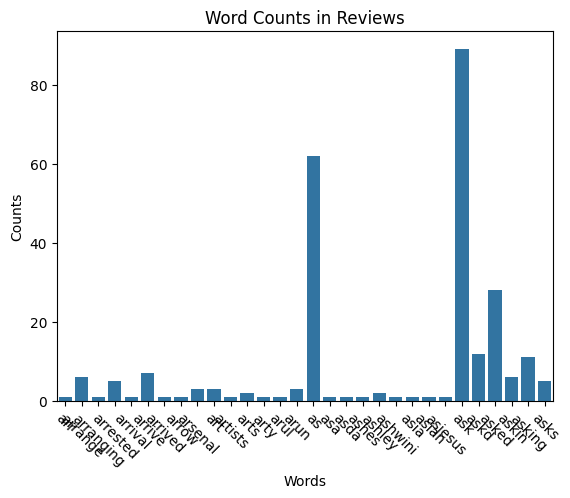

In [20]:
# Get word counts
word_counts = np.sum(X_vec.toarray(), axis=0)
# Get words
words = vectorizer.get_feature_names_out()

sns.barplot(x=words[1200:1230], y=word_counts[1200:1230])
plt.title("Word Counts in Reviews")
plt.xlabel("Words")
plt.ylabel("Counts")
plt.xticks(rotation=-45)
plt.show()

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(X['clean'])

word_df = df = pd.DataFrame(
  tfidf_matrix.toarray(),
  columns=vectorizer.get_feature_names_out()
)

word_df.head()


,00,000,000pes,008704050406,0089,0121,01223585236,01223585334,0125698789,02,...,zhong,zindgi,zoe,zogtorius,zoom,zouk,zyada,èn,ú1,〨ud
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


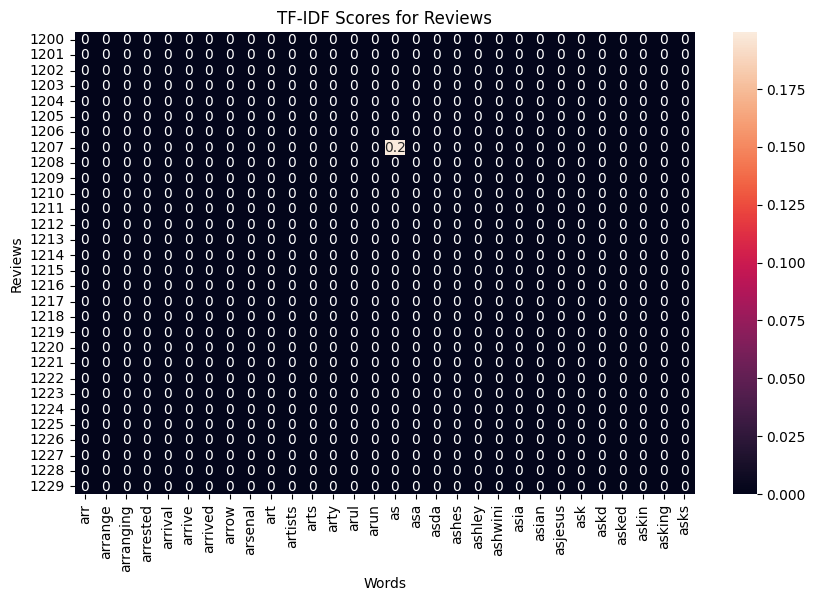

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(word_df.iloc[1200:1230, 1200:1230], annot=True)
plt.title("TF-IDF Scores for Reviews")
plt.xlabel("Words")
plt.ylabel("Reviews")
plt.show()

## Neural Networks for NLP

In [24]:
y = np.where(y == 'spam', 1, 0)

In [110]:
df['label'] = y
df.head()

,00,000,000pes,008704050406,0089,0121,01223585236,01223585334,0125698789,02,...,zindgi,zoe,zogtorius,zoom,zouk,zyada,èn,ú1,〨ud,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
import torch
import torch.nn as nn
import torchmetrics
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.nn import init
import torch.nn.functional as F

In [123]:
X = df.iloc[:, 1:-1].to_numpy()  
y = df.iloc[:, -1].to_numpy()

# Create a dataset
dataset = TensorDataset(torch.tensor(X).float(), torch.tensor(y).float())

# Print the first sample
input_sample, label_sample = dataset[2]
print('Input sample:', input_sample)
print('Label sample:', label_sample)

Input sample: tensor([0., 0., 0.,  ..., 0., 0., 0.])
Label sample: tensor(1.)


In [139]:
dataloader_train = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
)
# Get a batch of features and labels
features, labels = next(iter(dataloader_train))
print(features, labels)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]) tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])


In [248]:
class SpamModel(nn.Module):
    def __init__(self,in_features,out_features):
        super().__init__()
        # Define the three linear layers
        layer0 = nn.Linear(in_features,16)
        layer1 = nn.Linear(16,4)

        nn.init.kaiming_uniform_(layer0.weight)
        nn.init.kaiming_uniform_(layer1.weight)
        
        self.model= nn.Sequential(
            layer0,
            nn.ELU(),
            layer1,
            nn.Sigmoid(),
            nn.Linear(4,out_features),
        )
        
    def forward(self, x):
        return self.model(x)
    def train_model(self,data,criterion,optimizer,epoch_size=10):
        self.model.train()
        print("Training")
        for epoch in range(epoch_size):
            for features, labels in data:
                optimizer.zero_grad()
                pred = self.model(features)
                loss = criterion(pred,labels.view(-1,1))
                loss.backward()
                optimizer.step()
            print(f"epoch {epoch+1}/{epoch_size} lose = {loss.item()}")
        print("Finished")
in_features = X.shape[1]
out_features = 1
model = SpamModel(in_features,out_features)

In [249]:
epoch_size = 1
lr = .01
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(),lr=lr,momentum=0.9)

model.train_model(dataset,criterion,optimizer,epoch_size=epoch_size)

Training


/home/shk/.local/lib/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


epoch 1/1 lose = 0.014332517050206661
Finished


In [253]:
# Evaluate
# Set up binary accuracy metric
acc = torchmetrics.Accuracy(task='binary')

model.eval()
with torch.no_grad():
    for features, labels in dataset:
        # Get predicted probabilities for test data batch
        outputs = model(features)
        preds = (outputs >= 0.5).float()
        acc.update(preds, labels.view(outputs.shape))

# Compute total test accuracy
test_accuracy = acc.compute()
print(f"Test accuracy: {test_accuracy}")

Test accuracy: 0.985645055770874


# Test emails from my inbox

In [187]:
mine_tests = [
    """ Congratulations!

You can win an exclusive prize
Makita tool set
We appreciate your feedback!


You have been selected as one of the lucky few to have the unique opportunity to receive a brand new
Makita tool set!

To make a claim, simply answer a few quick questions about your experience with Lidl.
Get it now!"""
,
"""
You know that feeling when you’ve got all the right ingredients, but your site still comes out fragile, bloated. . . stale?
  

Well, we’ve been tweaking the recipe for shipping websites. Fast by default, durable over time, and easier to maintain after launch.
  

Just a heads up. The oven timer’s almost done!
""",
"""
 Oral-B Dental Set

You have been selected to receive an exclusive Level 1 Oral-B dental kit. This is your opportunity to enhance your oral hygiene routine with premium products from the leading brand in dental health.


"""
,
"""
Hey SHANKER4K, a friendly reminder if you could help us :)
Otherwise I understand and have a great week hehe,

Jessica,
""",
"""
Dear Member,

As one of the earliest to join Gradient Network, you've earned access to exclusive early benefits. These curated perks are our thank‑you for believing in the mission from the start.
""",
"""
* Note: You are receiving this platform-related update because you have an active Educative account. If you wish to unsubscribe from product or other updates related to your account, you can do so anytime.

 

Shanker,

 

A new AI course has been added to the Educative catalog:
"""
]

In [188]:
len(mine_tests)

6

In [190]:
# Function to preprocess new email data
def preprocess_email(email):
    email = email.apply(remove_punctuations)
    email = email.apply(remove_contractions)
    email = email.apply(remove_stopwords)
    sp_mail = email.apply(lambda x : nlp(x))
    email = sp_mail.apply(lemmatize_text)
    email = sp_mail.apply(remove_punctuation)
    return email



In [200]:
# Example: New email data
new_email = pd.Series(mine_tests)

# Preprocess the new email
preprocessed_email = preprocess_email(new_email)

# Vectorize the preprocessed email
vectorized_email = vectorizer.transform(preprocessed_email)

In [210]:
new_x = torch.FloatTensor(vectorized_email.toarray()[:,:-1])

In [250]:
# Predict using the trained model
prediction = (model.forward(new_x)>=0.5).float()

In [251]:
prediction

tensor([[1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.]])

In [252]:
# y_true = 3 spam, 3 ham
y_true = [1, 1, 1, 0, 0, 0]
print(classification_report(y_true, prediction))
print(confusion_matrix(y_true, prediction))

              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.67      0.80         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6

[[3 0]
 [1 2]]
